In [1]:
import numpy as np
import oyaml as yaml
import pandas as pd

from prismadv.project_manager.manager.base import ProjectManager
from prismadv.utils import get_project_root

In [2]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ['']

In [3]:
results_df = pd.DataFrame()
for dataset_name in dataset_name_options:
    project_manager = ProjectManager(project_root=get_project_root(), dataset_name=dataset_name)
    subtask_names = project_manager.get_available_subtasks()
    for subtask_name in subtask_names:
        processed_data_labels = project_manager.get_available_processed_data_labels_for_subtask(subtask_name)
        script_path_list = project_manager.get_available_script_path_list_for_subtask(subtask_name)
        script_names = [script_path.stem for script_path in script_path_list]
        for processed_data_label in processed_data_labels:
            if int(processed_data_label) == 0:
                continue
            for script_name in script_names:
                constraint_file = project_manager.get_task_agnostic_constraint_path(
                    subtask_name, processed_data_label) / "schema.pbtxt"
                constraint_validation_results_dir = project_manager.get_task_agnostic_constraints_validation_path(
                    subtask_name, processed_data_label)
                # for constraint_file in constraint_file_list:
                for is_clean in [True, False]:
                    if is_clean:
                        constraint_validation_result_path = constraint_validation_results_dir / f"validation_results_on_clean_test_data__{constraint_file.stem}.yaml"
                    else:
                        constraint_validation_result_path = constraint_validation_results_dir / f"validation_results_on_corrupted_test_data__{constraint_file.stem}.yaml"
                    try:
                        with open(constraint_validation_result_path, "r") as f:
                            validation_results = yaml.safe_load(f)
                    except FileNotFoundError:
                        continue
                    num_failed_error = len(
                        validation_results['anomalies'])
                    num_passed_warning = np.nan
                    num_failed_warning = np.nan
                    num_passed_error = np.nan
                    num_non_compilable = 0
                    total_constraints = 0
                    predicted_as_safe = (num_failed_error == 0)

                    execution_result_path = project_manager.get_execution_output_validation_path(
                        subtask_name, processed_data_label, script_name
                    ) / f"basic_metrics_evaluation.json"
                    try:
                        with open(execution_result_path, "r") as f:
                            execution_results = yaml.load(f, Loader=yaml.FullLoader)
                    except FileNotFoundError:
                        continue
                    if is_clean == True:
                        is_safe = execution_results['clean_data_is_safe']
                    else:
                        is_safe = execution_results['corrupted_data_is_safe']
                    new_row = {
                        "llm_name": "",
                        "llm_temperature": np.nan,
                        "dataset_name": dataset_name,
                        "subtask_name": subtask_name,
                        "processed_data_label": processed_data_label,
                        "script_name": script_name,
                        "is_clean": is_clean,
                        "num_passed_warning": num_passed_warning,
                        "num_failed_warning": num_failed_warning,
                        "num_failed_error": num_failed_error,
                        "num_passed_error": num_passed_error,
                        "num_non_compilable": num_non_compilable,
                        "total_constraints": total_constraints,
                        "predicted_as_safe": predicted_as_safe,
                        "is_safe": is_safe
                    }
                    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
df_all_unique = results_df

In [4]:
from workflow_prismadv.utils.results_analysis import format_results_latex, build_confusion_matrices

confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [5]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=1,
    model_label_prefix="tfdv",
    include_overall=True
)
print(latex_output)

%% === Dataset: students_anonymized ===
%% === Dataset: students ===
& \texttt{tfdv []} & 0.0 & 0.0 & 60 & 71 & 89 & 30 & 66.7\% & 45.8\% & 54.3\% \\
%% === Dataset: hr_analytics ===
& \texttt{tfdv []} & 0.0 & 0.0 & 49 & 118 & 122 & 11 & 81.7\% & 29.3\% & 43.2\% \\
%% === Dataset: sleep_health ===
& \texttt{tfdv []} & 0.0 & 0.0 & 61 & 112 & 109 & 43 & 58.7\% & 35.3\% & 44.0\% \\
%% === Dataset: IPL_win_prediction ===
& \texttt{tfdv []} & 0.0 & 0.0 & 103 & 106 & 74 & 92 & 52.8\% & 49.3\% & 51.0\% \\
%% === Dataset: imdb ===
& \texttt{tfdv []} & 0.0 & 0.0 & 79 & 68 & 62 & 41 & 65.8\% & 53.7\% & 59.2\% \\

%% === Overall (All Datasets Combined) ===
& \texttt{tfdv []} & 0.0 & 0.0 & 352 & 475 & 456 & 217 & 65.1\% & 42.7\% & 50.3\% \\


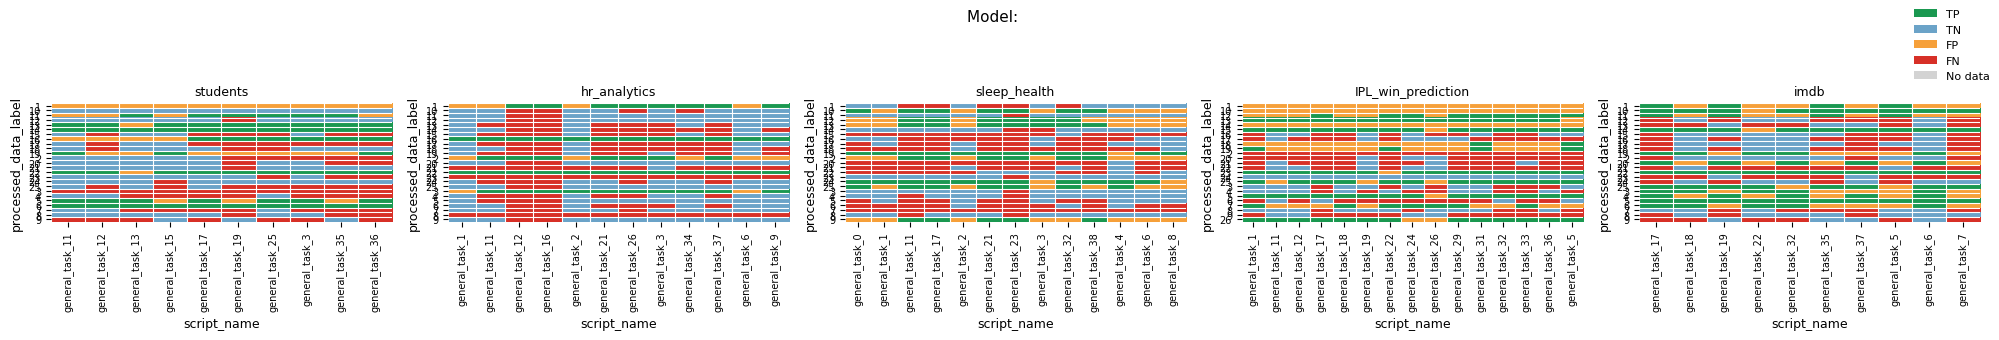

In [6]:
from workflow_prismadv.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)